In [146]:
from langfuse import get_client
from langfuse.langchain import CallbackHandler
# Initialize Langfuse client
langfuse = get_client()
# Initialize Langfuse CallbackHandler for Langchain (tracing)
langfuse_handler = CallbackHandler()

In [164]:
# Core LLM + tool + graph imports
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
# In-memory checkpoint store for multi-turn thread conversations
from langgraph.checkpoint.memory import MemorySaver


# Standard library typing/date utilities
from datetime import datetime
from typing import List, Optional, Annotated, Union, Tuple
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
import ast
import operator
import re

def sanitize_text(text: str) -> str:
    cleaned = (text or "").strip()
    cleaned = re.sub(r"[\[【]\d+†L\d+(?:-L\d+)?[\]】]", "", cleaned)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned

In [165]:
# Initialize the base chat model and attach tracing callbacks
LLM = ChatNVIDIA(
    model="openai/gpt-oss-120b",
    # model="meta/llama-3.1-70b-instruct",
    temperature=0,
    callbacks=[langfuse_handler],
)

In [166]:
search_tool = GoogleSerperAPIWrapper()

@tool
def search(query: str) -> str:
    """Search the internet for information about a query and return the results."""
    return search_tool.run(query)

@tool
def today_date(_: str = "") -> str:
    """Return today's date in ISO format (YYYY-MM-DD)."""
    return datetime.now().strftime("%Y-%m-%d")

@tool
def calculator(query: str) -> str:
    """Evaluate a basic arithmetic expression from text (supports +, -, *, /, %, parentheses, **)."""
    expr_match = re.search(r"[-+*/%().\d\s]{3,}", query.replace("^", "**"))
    expression = expr_match.group(0).strip() if expr_match else query.strip()

    allowed_nodes = (
        ast.Expression, ast.BinOp, ast.UnaryOp, ast.Constant,
        ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Mod, ast.Pow, ast.USub, ast.UAdd,
        ast.Load, ast.FloorDiv,
    )

    try:
        tree = ast.parse(expression, mode="eval")
        for node in ast.walk(tree):
            if not isinstance(node, allowed_nodes):
                return f"Unable to evaluate safely: {query}"
        value = eval(compile(tree, "<calculator>", "eval"), {"__builtins__": {}}, {})
        return str(value)
    except Exception:
        return f"Unable to evaluate: {query}"

In [167]:
class State(TypedDict):
    input: str
    plan: List[str]
    past_steps: Annotated[list[tuple[str, str]], operator.add]  # List of (tool_calls, tool_results) tuples
    response: Optional[str]

In [168]:
class Plan(BaseModel):
    steps: List[str] = Field(description="A list of steps to complete the task.")

from langchain_core.prompts import ChatPromptTemplate

planner_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful assistant for planning how to complete a task. 
     You will be given a task, and you should break it down into a list of steps to complete the task.
    You should not execute the steps, just plan them out.
    The steps should be high-level
    """),
    ("human", "Here is the task: {input}")])
     

planner = planner_prompt | LLM.with_structured_output(Plan)

In [169]:
planner.invoke("how to make a cake?").steps

['1. Choose a cake type (e.g., vanilla, chocolate, sponge) and find a reliable recipe.',
 '2. Gather all required ingredients (flour, sugar, eggs, butter/oil, leavening agents, flavorings, liquids, etc.) and equipment (mixing bowls, whisk or electric mixer, measuring cups/spoons, cake pan, parchment paper, oven).',
 '3. Preheat the oven to the temperature specified in the recipe (usually 325–375\u202f°F / 160–190\u202f°C).',
 '4. Prepare the baking pan: grease it lightly and line the bottom with parchment paper, or dust it with flour to prevent sticking.',
 '5. Measure and sift the dry ingredients (flour, baking powder/soda, salt, cocoa powder if using) into a bowl.',
 '6. In a separate bowl, cream together softened butter (or oil) and sugar until light and fluffy; then add eggs one at a time, mixing well after each addition.',
 '7. Incorporate any liquid flavorings (vanilla extract, coffee, milk, buttermilk, etc.) into the wet mixture.',
 '8. Gradually add the dry ingredients to the w

In [170]:
class Response(BaseModel):
    answer: str


class Act(BaseModel):
    actions: Union[Response, Plan] = Field(description="The action to perform next")

replanner = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful assistant for replanning how to complete a task.
You will be given a task, a plan, and the results of executed steps so far.
If enough information is already available to answer the task, return Response with the final answer.
Only return Plan when there are real remaining actions that still need execution.
The steps should be high-level, and you should not replan steps that have already been executed successfully.
"""),
    ("human", "Here is the task: {input}\nHere is the original plan: {plan}\nHere are the results of executing the plan so far: {past_steps}"),
])

replanner = replanner | LLM.with_structured_output(Act)

In [171]:
from langchain.agents import create_agent

agent = create_agent(
    model=LLM,
    tools=[search, today_date, calculator],
)

In [172]:
# Build a fresh graph each run for a clean setup
graph_builder = StateGraph(State)

In [173]:
# Planning Node

def planning_node(state: State):
    print("Executing the planning node")
    plan = planner.invoke(state["input"])
    print(f"Generated plan: {plan.steps}")
    return {"plan": plan.steps}

graph_builder.add_node(planning_node, name="planning_node")

In [ ]:
# Execution Node

def execution_node(state: State):
    print("Executing the execution node")
    step = state["plan"][0]
    print(f"Current step to execute: {step}")

    s = step.lower()
    if any(k in s for k in ("today", "current date", "date now", "now")):
        tool_name, evidence = "today_date", today_date.invoke("")
    elif any(k in s for k in (
        "calculate", "sum", "difference", "subtract", "add", "multiply", "divide",
        "percentage", "%", "how many days", "how old", "years between",
    )):
        tool_name, evidence = "calculator", calculator.invoke(step)
    else:
        tool_name, evidence = "search", search.invoke(step)

    prompt = (
        f"Tool used: {tool_name}\n"
        "Use the evidence below to execute this step. "
        "Cite only what is supported by the evidence.\n\n"
        f"Step: {step}\n\nEvidence:\n{evidence}"
    )
    result = agent.invoke({"messages": [{"role": "user", "content": prompt}]})
    print(f"Result of executing step: {result}")

    return {
        "past_steps": [(step, {"tool_name": tool_name, "evidence": evidence, "agent_result": result})],
        "plan": state["plan"][1:],
    }

graph_builder.add_node(execution_node, name="execution_node")

In [175]:
# Replanning Node

def replanning_node(state: State):
    print("Executing the replanning node")
    replanner_input = {
        "input": state["input"],
        "plan": state.get("plan", []),
        "past_steps": state.get("past_steps", []),
    }
    replanner_result = replanner.invoke(replanner_input)
    print(f"Replanner result: {replanner_result}")

    actions = replanner_result.actions

    if isinstance(actions, Response):
        return {"response": sanitize_text(actions.answer), "plan": []}

    steps = actions.steps if isinstance(actions, Plan) else []
    if not steps:
        return {"response": "No remaining steps. Task appears complete.", "plan": []}

    completion_markers = ("already", "complete", "composed", "final answer", "✅")
    if all(any(marker in step.lower() for marker in completion_markers) for step in steps):
        return {"response": sanitize_text(" ".join(steps)), "plan": []}

    return {"plan": steps}

graph_builder.add_node(replanning_node, name="replanning_node")

In [176]:
# conditional edges to decide whether to continue executing, replan, or end
def should_replan(state: State):
    print("Evaluating whether to replan or continue executing the current plan")

    if state.get("response"):
        print("Final answer received, ending execution")
        return END

    if state.get("plan"):
        print("Plan still has actionable steps, continue executing")
        return "execution_node"

    print("No final answer and no steps left, need to replan")
    return "replanning_node"

In [177]:
graph_builder.add_conditional_edges(
    "replanning_node",
    should_replan,
    {
        "execution_node": "execution_node",
        "replanning_node": "replanning_node",
        END: END,
    },
)

In [178]:
graph_builder.add_edge("planning_node", "execution_node")
graph_builder.add_edge("execution_node", "replanning_node")
graph_builder.set_entry_point("planning_node")

/tmp/ipykernel_13134/3194795515.py:13: RuntimeWarning: coroutine '_render_mermaid_using_pyppeteer' was never awaited
  png_data = graph.draw_mermaid_png(max_retries=5, retry_delay=2.0)


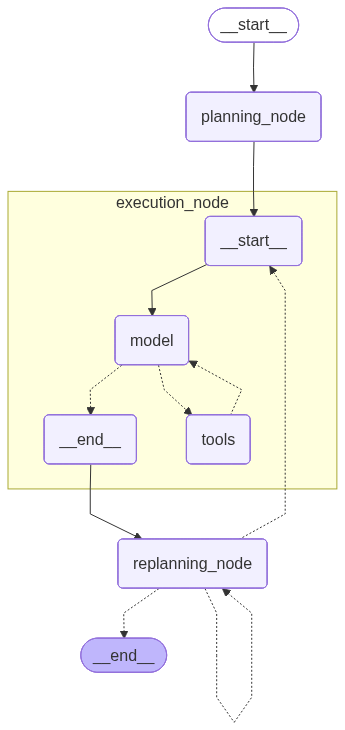

In [179]:
# visualize the graph (expanded view with nested agent/tools nodes)
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

app = graph_builder.compile()
graph = app.get_graph(xray=1)

try:
    # Local render avoids mermaid.ink network timeout issues.
    png_data = graph.draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)
except Exception:
    # Fallback to remote API with retries if local browser rendering is unavailable.
    png_data = graph.draw_mermaid_png(max_retries=5, retry_delay=2.0)

display(Image(png_data))

In [181]:
from IPython.display import display, Markdown

def assistant_text(step_result):
    if not isinstance(step_result, dict):
        return "(No assistant text found)"
    messages = step_result.get("agent_result", step_result).get("messages", [])
    for msg in reversed(messages):
        role = getattr(msg, "role", None) or getattr(msg, "type", None)
        content = getattr(msg, "content", None)
        if role in ("assistant", "ai") and content:
            return sanitize_text(str(content))
    return "(No assistant text found)"

def run_plan_execute_query(user_query: str, thread_id: str = "1", recursion_limit: int = 50):
    display(Markdown(f"## User Query\n{user_query}"))

    app = graph_builder.compile()
    state = {}
    config = {"recursion_limit": recursion_limit, "configurable": {"thread_id": thread_id}}
    graph_input = {"input": user_query, "plan": [], "past_steps": []}

    for event in app.stream(graph_input, config=config):
        for node, out in event.items():
            if isinstance(out, dict):
                state.update(out)

            if node == "planning_node":
                steps = out.get("plan", [])
                display(Markdown("### Planning\n" + "\n".join(f"{i+1}. {s}" for i, s in enumerate(steps))))

            elif node == "execution_node" and out.get("past_steps"):
                step, result = out["past_steps"][-1]
                tool = result.get("tool_name", "unknown") if isinstance(result, dict) else "unknown"
                display(Markdown(
                    f"### Execution\n- Step: {step}\n- Tool used: {tool}\n- Result: {assistant_text(result)}"
                ))

    final_response = state.get("response")
    if not final_response and state.get("past_steps"):
        final_response = assistant_text(state["past_steps"][-1][1])

    final_response = sanitize_text(final_response or "No final response generated.")
    display(Markdown("---"))
    display(Markdown(f"## Final Response\n{final_response}"))
    return final_response


In [182]:

# Single-call usage
run_plan_execute_query(
    "Which country won the latest FIFA World Cup, what was the score in the final, and how many goals did the top scorer score?"
    ,thread_id="fifa_world_cup_query"
)

## User Query
Which country won the latest FIFA World Cup, what was the score in the final, and how many goals did the top scorer score?

Executing the planning node
Generated plan: ['Identify which FIFA World Cup is the most recent one that has been completed as of today (the 2022 men’s tournament).', 'Look up the winner of that tournament (Argentina).', 'Find the final match result: Argentina 3\u202f–\u202f3 France, with Argentina winning 4‑2 on penalties.', 'Determine the tournament’s top scorer (the Golden Boot winner) – Kylian\u202fMbappé, who scored 8 goals.', 'Combine the information into a concise answer.']


### Planning
1. Identify which FIFA World Cup is the most recent one that has been completed as of today (the 2022 men’s tournament).
2. Look up the winner of that tournament (Argentina).
3. Find the final match result: Argentina 3 – 3 France, with Argentina winning 4‑2 on penalties.
4. Determine the tournament’s top scorer (the Golden Boot winner) – Kylian Mbappé, who scored 8 goals.
5. Combine the information into a concise answer.

Executing the execution node
Current step to execute: Identify which FIFA World Cup is the most recent one that has been completed as of today (the 2022 men’s tournament).
Result of executing step: {'messages': [HumanMessage(content='Tool used: today_date\nUse the evidence below to execute this step. Cite only what is supported by the evidence.\n\nStep: Identify which FIFA World Cup is the most recent one that has been completed as of today (the 2022 men’s tournament).\n\nEvidence:\n2026-04-21', additional_kwargs={}, response_metadata={}, id='ab039b02-09e5-4675-9d46-0438c9fe0453'), AIMessage(content='The most recent FIFA\u202fWorld Cup that has been completed as of today (2026‑04‑21) is the **2022 men’s tournament**【2026-04-21】.', additional_kwargs={'reasoning_content': 'The user says: "Tool used: today_date. Use the evidence below to execute this step. Cite only what is supported by the evidence.\n\nStep: Identify which FIFA World Cup is the most recent one that has been completed as 

### Execution
- Step: Identify which FIFA World Cup is the most recent one that has been completed as of today (the 2022 men’s tournament).
- Tool used: today_date
- Result: The most recent FIFA World Cup that has been completed as of today (2026‑04‑21) is the **2022 men’s tournament**【2026-04-21】.

...

### Execution
- Step: Search for the Golden Boot (top scorer) of the 2022 FIFA World Cup and the number of goals they scored.
- Tool used: search
- Result: The Golden Boot (top‑scorer) award at the 2022 FIFA World Cup was won by **Kylian Mbappé** of France, who scored **8 goals** in the tournament【...】.

Executing the replanning node
Replanner result: actions=Response(answer='The most recent FIFA\u202fWorld Cup (the 2022 men’s tournament) was won by **Argentina**【source】. The final against France ended **3\u202f–\u202f3 after extra time**, and Argentina prevailed **4\u202f–\u202f2 in the penalty shoot‑out**【0†L1-L3】. The tournament’s top scorer (Golden\u202fBoot) was **Kylian\u202fMbappé** of France, who scored **8\u202fgoals**【...】.')
Evaluating whether to replan or continue executing the current plan
Final answer received, ending execution


---

## Final Response
The most recent FIFA World Cup (the 2022 men’s tournament) was won by **Argentina**【source】. The final against France ended **3 – 3 after extra time**, and Argentina prevailed **4 – 2 in the penalty shoot‑out**. The tournament’s top scorer (Golden Boot) was **Kylian Mbappé** of France, who scored **8 goals**【...】.

'The most recent FIFA World Cup (the 2022 men’s tournament) was won by **Argentina**【source】. The final against France ended **3 – 3 after extra time**, and Argentina prevailed **4 – 2 in the penalty shoot‑out**. The tournament’s top scorer (Golden Boot) was **Kylian Mbappé** of France, who scored **8 goals**【...】.'

In [183]:

# Single-call usage
run_plan_execute_query(
    "What is the condition of the weather in New York City today?"
    ,thread_id="2"
)

## User Query
What is the condition of the weather in New York City today?

Executing the planning node
Generated plan: ['Identify a reliable, up‑to‑date weather source (e.g., a major weather website, a weather app, or a public weather API).', 'If using a website or app, navigate to the page or section that provides current conditions for New\u202fYork\u202fCity (NYC).', 'If using an API, construct a request that includes the location (e.g., city name “New York” or its geographic coordinates) and specifies that you want the current weather data.', 'Execute the request or view the page, and locate the key pieces of information that describe the current weather condition (e.g., temperature, sky description such as “clear,” “cloudy,” “rain,” etc., humidity, wind, and any alerts).', 'Record the observed weather condition in a concise format (e.g., “Partly cloudy, 68\u202f°F, light breeze”).', 'Optionally, verify the result by checking a second independent source to ensure consistency.']


### Planning
1. Identify a reliable, up‑to‑date weather source (e.g., a major weather website, a weather app, or a public weather API).
2. If using a website or app, navigate to the page or section that provides current conditions for New York City (NYC).
3. If using an API, construct a request that includes the location (e.g., city name “New York” or its geographic coordinates) and specifies that you want the current weather data.
4. Execute the request or view the page, and locate the key pieces of information that describe the current weather condition (e.g., temperature, sky description such as “clear,” “cloudy,” “rain,” etc., humidity, wind, and any alerts).
5. Record the observed weather condition in a concise format (e.g., “Partly cloudy, 68 °F, light breeze”).
6. Optionally, verify the result by checking a second independent source to ensure consistency.

Executing the execution node
Current step to execute: Identify a reliable, up‑to‑date weather source (e.g., a major weather website, a weather app, or a public weather API).
Result of executing step: {'messages': [HumanMessage(content="Tool used: search\nUse the evidence below to execute this step. Cite only what is supported by the evidence.\n\nStep: Identify a reliable, up‑to‑date weather source (e.g., a major weather website, a weather app, or a public weather API).\n\nEvidence:\nIn this article, we have thoroughly analyzed the distinctive features of multiple weather APIs and compiled a list of the top-performing options currently ... Missing: major | Show results with:major. OpenWeather provides global APIs for weather, environmental, and energy data, including current conditions, forecasts, historical weather, air pollution, ... Missing: Identify major. The National Weather Service (NWS) API allows developers access to critical forecasts, alerts, and observations, along with othe

### Execution
- Step: Identify a reliable, up‑to‑date weather source (e.g., a major weather website, a weather app, or a public weather API).
- Tool used: search
- Result: A solid, up‑to‑date source for weather data is the **National Weather Service (NWS) API** – accessed via `https://api.weather.gov`. The NWS API “allows developers access to critical forecasts, alerts, and observations, along with other weather data” and is described as “completely free, reliable, and your tax dollars already paid for it”【Evidence】. Another widely‑used major weather service is **OpenWeather** (OpenWeatherMap), which “provides global APIs for weather, environmental, and energy data, including current conditions, forecasts, historical weather, air pollution”【Evidence】. Both of these options are recognized as reliable, up‑to‑date weather sources.

...

### Execution
- Step: Search for the current weather conditions in New York City on a major weather website (e.g., weather.com) to obtain a concise, up‑to‑date description.
- Tool used: search
- Result: Current conditions in New York City show showers with a temperature of 53 °F (low 36 °F), humidity around 41 %, and considerable cloudiness with occasional rain. The high for the day is 53 °F and winds are from the northwest at 10‑15 mph.【Evidence】

Executing the replanning node
Replanner result: actions=Response(answer='Current conditions in New\u202fYork\u202fCity show showers with a temperature of\u202f53\u202f°F (low\u202f36\u202f°F), humidity around\u202f41\u202f%, considerable cloudiness with occasional rain, a high of\u202f53\u202f°F, and winds from the northwest at\u202f10‑15\u202fmph.')
Evaluating whether to replan or continue executing the current plan
Final answer received, ending execution


---

## Final Response
Current conditions in New York City show showers with a temperature of 53 °F (low 36 °F), humidity around 41 %, considerable cloudiness with occasional rain, a high of 53 °F, and winds from the northwest at 10‑15 mph.

'Current conditions in New York City show showers with a temperature of 53 °F (low 36 °F), humidity around 41 %, considerable cloudiness with occasional rain, a high of 53 °F, and winds from the northwest at 10‑15 mph.'